# 01. Life Contingencies: The Pure Endowment Model (${}_{n}E_{x}$)

The **Pure Endowment** is the most fundamental building block of life contingencies. It represents a contract that pays a fixed sum (usually normalized to 1) at a specific future date $n$, provided the policyholder $(x)$ is still alive.

### The Actuarial Formula

The Actuarial Present Value (APV) is calculated by combining financial discounting with the probability of survival:

$${}_{n}E_{x} = v^{n} \cdot {}_{n}p_{x}$$

**Where:**

* $v^{n} = (1 + i)^{-n}$ is the **Financial Discount Factor**, accounting for the time value of money at interest rate $i$.
* ${}_{n}p_{x} = \frac{l_{x+n}}{l_{x}}$ is the **Probability of Survival**, representing the likelihood that an individual aged $x$ reaches age $x+n$ based on a specific mortality table.

### Real-World Application: Education Savings Policies

In the Kenyan insurance market, this model is the core engine for **Education Endowment Products**.

**Scenario:**
A parent in Eldoret wants to secure a payout of **KES 1,000,000** for their child’s university fees in 15 years. The insurance company must determine the "Net Single Premium" to charge today.

By using the Pure Endowment model, the insurer ensures that the premium collected today, when invested at the prevailing **CBK Risk-Free Rate**, will grow to the target amount, while also accounting for the statistical probability that the benefit will actually be paid out (contingent on survival).

In [6]:
import pandas as pd
import numpy as np

def generate_gompertz_table(omega=100, B=0.0003, C=1.07):
    """Generates a survival curve (lx) using Gompertz Law."""
    ages = np.arange(0, omega + 1)
    lx = 100000 * np.exp(-(B / np.log(C)) * (C**ages - 1))
    return pd.DataFrame({'lx': lx}, index=ages)

def calculate_pure_endowment(age, term, market_rate, mortality_table):
    """
    Returns the Net Single Premium (APV) as a single float.
    """
    omega = mortality_table.index.max()
    if age + term > omega:
        return 0.0

    v_n = (1 + market_rate) ** -term
    n_p_x = mortality_table.loc[age + term, 'lx'] / mortality_table.loc[age, 'lx']
    
    return float(v_n * n_p_x)

# Execution with Kenyan Market Interest Rates (approx 10%)
current_age = 30
policy_term = 20
market_rate = 0.10 
mortality_table = generate_gompertz_table()

premium = calculate_pure_endowment(current_age, policy_term, market_rate, mortality_table)

print(f"Refined Net Single Premium (NSP): {premium:.5f}")
print(f"For KES 1M Benefit, pay: KES {premium * 1_000_000:,.2f}")

Refined Net Single Premium (NSP): 0.13492
For KES 1M Benefit, pay: KES 134,921.28


### Visualization of Sensitivity

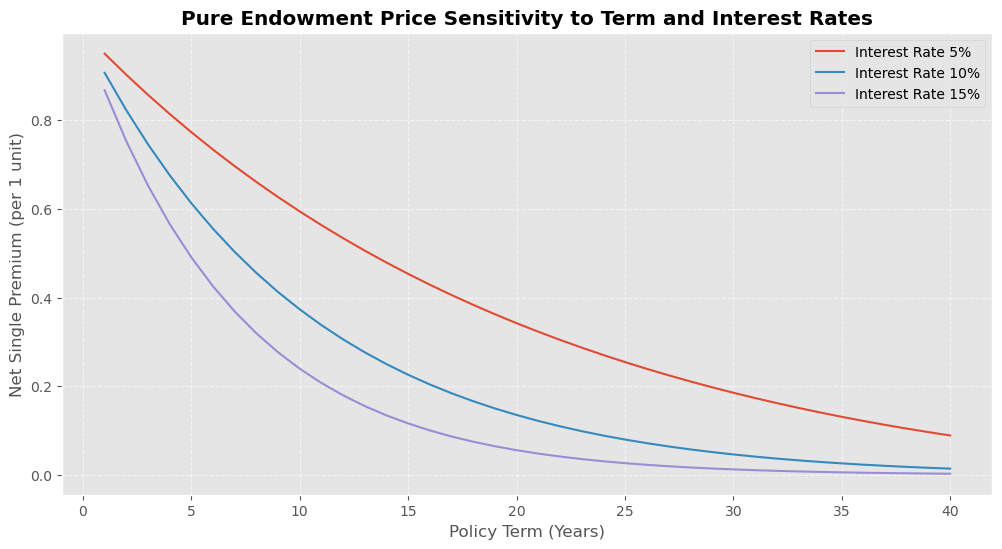

In [7]:
# Sensitivity Analysis: Comparing 5% (Low) vs 10% (Market) vs 15% (High) rates
import matplotlib.pyplot as plt

terms = np.arange(1, 41)
rates = [0.05, 0.10, 0.15] # Different interest rates for sensitivity analysis

plt.figure(figsize=(12, 6))

for r in rates:
    premiums = [calculate_pure_endowment(30, t, r, mortality_table) for t in terms]
    plt.plot(terms, premiums, label=f'Interest Rate {r*100:.0f}%')

plt.title("Pure Endowment Price Sensitivity to Term and Interest Rates", fontweight='bold')
plt.xlabel("Policy Term (Years)")
plt.ylabel("Net Single Premium (per 1 unit)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Parting Shot: Real-World Applications Beyond Education

While we focused on education policies, the **Pure Endowment** concept, the principle of "payment contingent on survival", is a fundamental building block across several high-value domains:

-   **Mortgage Protection (Low-Cost Endowments):** Many homeowners take out pure endowment policies that mature exactly when their mortgage ends. If they survive the term, the payout is used to clear the final principal of the loan.
    
-   **Executive Compensation & Retention:** Large firms use "Golden Handcuffs", a pure endowment structure where a high-performing executive receives a massive bonus only if they remain with the company (survive professionally) for a set number of years (e.g., a 5-year vesting period).
    
-   **Pension Fund "Return of Premium" Riders:** Some pension schemes use pure endowment calculations to determine the cost of adding a "survivorship bonus" to a pool of retirees. It helps in redistributing the funds of those who pass away early to those who live longer.
    
-   **Estate Planning & Wealth Transfer:** It is often used as a risk-free tool for transferring wealth to the next generation at a specific age (e.g., a child’s 25th birthday), ensuring the capital is preserved and only released when the beneficiary is likely to have reached financial maturity.
    
-   **Corporate Debt Redemption:** Companies often set up "Sinking Funds" based on pure endowment principles to ensure they have the cash to pay off corporate bonds upon maturity, provided the business entity remains solvent (the corporate version of "survival").